<a href="https://colab.research.google.com/github/joyngeno21-ui/Joy-AI-Assignment/blob/main/Notebooks/Chap09/9_4_Bayesian_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 9.4: Bayesian approach**

This notebook investigates the Bayesian approach to model fitting and reproduces figure 9.11 from the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.


In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
# Define seed to get same results each time
np.random.seed(1)

In [2]:
# The true function that we are trying to estimate, defined on [0,1]
def true_function(x):
    y = np.exp(np.sin(x*(2*3.1413)))
    return y

In [3]:
# Generate some data points with or without noise
def generate_data(n_data, sigma_y=0.3):
    # Generate x values quasi uniformly
    x = np.ones(n_data)
    for i in range(n_data):
        x[i] = np.random.uniform(i/n_data, (i+1)/n_data, 1)

    # y value from running through function and adding noise
    y = np.ones(n_data)
    for i in range(n_data):
        y[i] = true_function(x[i])
        y[i] += np.random.normal(0, sigma_y, 1)
    return x,y

In [4]:
# Draw the fitted function, together with uncertainty used to generate points
def plot_function(x_func, y_func, x_data=None,y_data=None, x_model = None, y_model =None, sigma_func = None, sigma_model=None):

    fig,ax = plt.subplots()
    ax.plot(x_func, y_func, 'k-')
    if sigma_func is not None:
      ax.fill_between(x_func, y_func-2*sigma_func, y_func+2*sigma_func, color='lightgray')

    if x_data is not None:
        ax.plot(x_data, y_data, 'o', color='#d18362')

    if x_model is not None:
        ax.plot(x_model, y_model, '-', color='#7fe7de')

    if sigma_model is not None:
      ax.fill_between(x_model, y_model-2*sigma_model, y_model+2*sigma_model, color='lightgray')

    ax.set_xlim(0,1)
    ax.set_xlabel('Input, $x$')
    ax.set_ylabel('Output, $y$')
    plt.show()

/tmp/ipykernel_1423/2000407647.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x[i] = np.random.uniform(i/n_data, (i+1)/n_data, 1)
/tmp/ipykernel_1423/2000407647.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[i] += np.random.normal(0, sigma_y, 1)


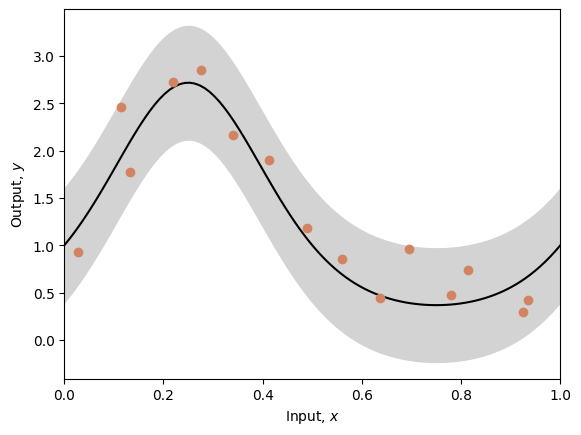

In [5]:
# Generate true function
x_func = np.linspace(0, 1.0, 100)
y_func = true_function(x_func);

# Generate some data points
np.random.seed(1)
sigma_func = 0.3
n_data = 15
x_data,y_data = generate_data(n_data, sigma_func)

# Plot the function, data and uncertainty
plot_function(x_func, y_func, x_data, y_data, sigma_func=sigma_func)

In [12]:
def network(x, beta, omega):
    # Retrieve number of hidden units
    n_hidden = omega.shape[0]

    y = np.zeros_like(x)
    for c_hidden in range(n_hidden):
        # Evaluate activations based on shifted lines (figure 8.4b-d)
        line_vals =  x  - c_hidden/n_hidden
        h =  line_vals * (line_vals > 0)
        # Weight activations by omega parameters and sum
        y = y + omega[c_hidden, 0] * h # Access omega as a column vector
    # Add bias, beta
    y = y + beta[0] # Access beta as a scalar from a 1x1 array

    return y

Now let's compute a probability distribution over the model parameters using Bayes's rule:

\begin{equation}
 Pr(\boldsymbol\phi|\{\mathbf{x}_{i},\mathbf{y}_{i}\}) = \frac{\prod_{i=1}^{I} Pr(\mathbf{y}_{i}|\mathbf{x}_{i},\boldsymbol\phi) Pr(\boldsymbol\phi)}{\int \prod_{i=1}^{I} Pr(\mathbf{y}_{i}|\mathbf{x}_{i},\boldsymbol\phi) Pr(\boldsymbol\phi)d\boldsymbol\phi } ,
\end{equation}

We'll define the prior $Pr(\boldsymbol\phi)$ as:

\begin{equation}
Pr(\boldsymbol\phi) = \text{Norm}_{\boldsymbol\phi}\bigl[\mathbf{0},\sigma^2_p\mathbf{I}\bigr]
\end{equation}

where $\phi=[\omega_1,\omega_2\ldots \omega_n, \beta]^T$ and $\sigma^2_{p}$  is the prior variance.

The likelihood term $\prod_{i=1}^{I} Pr(\mathbf{y}_{i}|\mathbf{x}_{i},\boldsymbol\phi)$ is given by:

\begin{align}
\prod_{i=1}^{I} Pr(\mathbf{y}_{i}|\mathbf{x}_{i},\boldsymbol\phi) &=& \prod_{i=1}^{I} \text{Norm}_{y_i}\bigl[\text{f}[\mathbf{x}_{i},\boldsymbol\phi],\sigma_d^2\bigr]\\
&=& \prod_{i=1}^{I} \text{Norm}_{y_i}\bigl[\boldsymbol\omega\mathbf{h}_i+\beta,\sigma_d^2\bigr]\\
&=& \text{Norm}_{\mathbf{y}}\bigl[\mathbf{H}^T\boldsymbol\phi,\sigma^2\mathbf{I}\bigr].
\end{align}

where $\sigma^2$ is the measurement noise and $\mathbf{h}_{i}$ is the column vector of hidden variables for the $i^{th}$ input.  Here the vector $\mathbf{y}$ and matrix $\mathbf{H}$ are defined as:

\begin{equation}
\mathbf{y} = \begin{bmatrix}y_1\\y_2\\\vdots\\y_{I}\end{bmatrix}\quad\text{and}\quad \mathbf{H} = \begin{bmatrix}\mathbf{h}_{1}&\mathbf{h}_{2}&\cdots&\mathbf{h}_{I}\\1&1&\cdots &1\end{bmatrix}.
\end{equation}


To make progress we use the change of variable relation (Appendix C.3.4 of the book) to rewrite the likelihood term as a normal distribution in the parameters $\boldsymbol\phi$:

\begin{align}
\prod_{i=1}^{I} Pr(\mathbf{y}_{i}|\mathbf{x}_{i},\boldsymbol\phi+\beta)
&=& \text{Norm}_{\mathbf{y}}\bigl[\mathbf{H}^T\boldsymbol\phi,\sigma^2\bigr]\\
&\propto& \text{Norm}_{\boldsymbol\phi}\bigl[(\mathbf{H}\mathbf{H}^T)^{-1}\mathbf{H}\mathbf{y},\sigma^2(\mathbf{H}\mathbf{H}^t)^{-1}\bigr]
\end{align}


Finally, we can combine the likelihood and prior terms using the product of two normal distributions relation (Appendix C.3.3).

\begin{align}
 Pr(\boldsymbol\phi|\{\mathbf{x}_{i},\mathbf{y}_{i}\}) &\propto& \prod_{i=1}^{I} Pr(\mathbf{y}_{i}|\mathbf{x}_{i},\boldsymbol\phi) Pr(\boldsymbol\phi)\\
 &\propto&\text{Norm}_{\boldsymbol\phi}\bigl[(\mathbf{H}\mathbf{H}^T)^{-1}\mathbf{H}\mathbf{y},\sigma^2(\mathbf{H}\mathbf{H}^T)^{-1}\bigr] \text{Norm}_{\boldsymbol\phi}\bigl[\mathbf{0},\sigma^2_p\mathbf{I}\bigr]\\
 &\propto&\text{Norm}_{\boldsymbol\phi}\biggl[\frac{1}{\sigma^2}\left(\frac{1}{\sigma^2}\mathbf{H}\mathbf{H}^T+\frac{1}{\sigma_p^2}\mathbf{I}\right)^{-1}\mathbf{H}\mathbf{y},\left(\frac{1}{\sigma^2}\mathbf{H}\mathbf{H}^T+\frac{1}{\sigma_p^2}\mathbf{I}\right)^{-1}\biggr].
\end{align}

In fact, since this is already a normal distribution, the constant of proportionality must be one and we can write

\begin{align}
 Pr(\boldsymbol\phi|\{\mathbf{x}_{i},\mathbf{y}_{i}\}) &=& \text{Norm}_{\boldsymbol\phi}\biggl[\frac{1}{\sigma^2}\left(\frac{1}{\sigma^2}\mathbf{H}\mathbf{H}^T+\frac{1}{\sigma_p^2}\mathbf{I}\right)^{-1}\mathbf{H}\mathbf{y},\left(\frac{1}{\sigma^2}\mathbf{H}\mathbf{H}^T+\frac{1}{\sigma_p^2}\mathbf{I}\right)^{-1}\biggr].
\end{align}

TODO -- On a piece of paper, use the relations in Appendix C.3.3 and C.3.4 to fill in the missing steps and establish that this is the correct formula for the posterior.

In [13]:
def compute_H(x_data, n_hidden):
  n_data = x_data.size
  # Initialize H matrix with n_hidden + 1 rows (for hidden units and bias) and n_data columns
  H = np.zeros((n_hidden + 1, n_data))

  for i in range(n_hidden):
    for j in range(n_data):
      # Compute preactivation based on shifted ReLU (x - c_hidden/n_hidden)
      line_vals = x_data[j] - i/n_hidden
      # Apply ReLU to get activation
      H[i,j] = np.maximum(0, line_vals)

  # The last row of H is for the bias term, which is always 1
  H[n_hidden, :] = 1

  return H

def compute_param_mean_covar(x_data, y_data, n_hidden, sigma_sq, sigma_p_sq):
  # Retrieve the matrix containing the hidden variables
  H = compute_H(x_data, n_hidden) ;

  # The text indicates y is a column vector, so reshape y_data
  y_data_col = y_data.reshape(-1, 1)

  # Compute the covariance matrix
  # phi_covar = (1/sigma_sq * H @ H.T + 1/sigma_p_sq * I)^-1
  term1 = (1/sigma_sq) * np.matmul(H, np.transpose(H))
  term2 = (1/sigma_p_sq) * np.identity(n_hidden+1)
  phi_covar = np.linalg.inv(term1 + term2)

  # Compute the mean matrix
  # phi_mean = 1/sigma_sq * phi_covar @ H @ y
  phi_mean = (1/sigma_sq) * np.matmul(np.matmul(phi_covar, H), y_data_col)

  return phi_mean, phi_covar

Now we can draw samples from this distribution

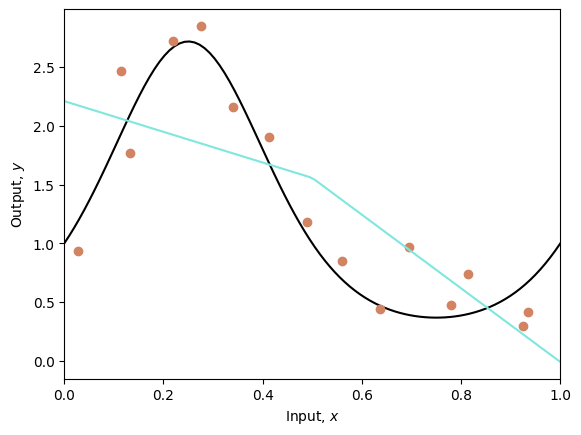

In [17]:
# Define parameters
n_hidden = 5
sigma_sq = sigma_func * sigma_func
# Arbitrary large value reflecting the fact we are uncertain about the
# parameters before we see any data
sigma_p_sq = 1

# Compute the mean and covariance matrix
phi_mean, phi_covar = compute_param_mean_covar(x_data, y_data, n_hidden, sigma_sq, sigma_p_sq)

# Let's draw the mean model
x_model = x_func
y_model_mean = network(x_model, phi_mean[-1], phi_mean[0:n_hidden])
plot_function(x_func, y_func, x_data, y_data, x_model, y_model_mean)

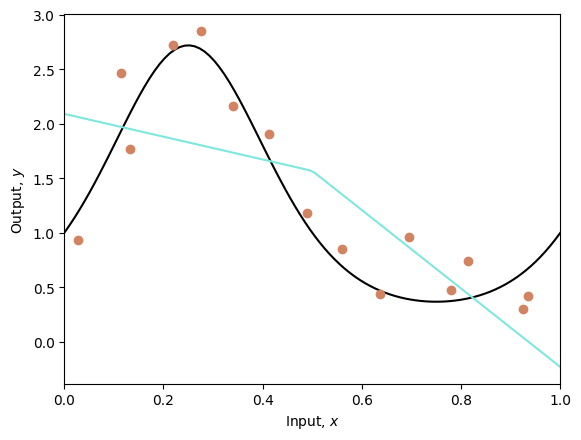

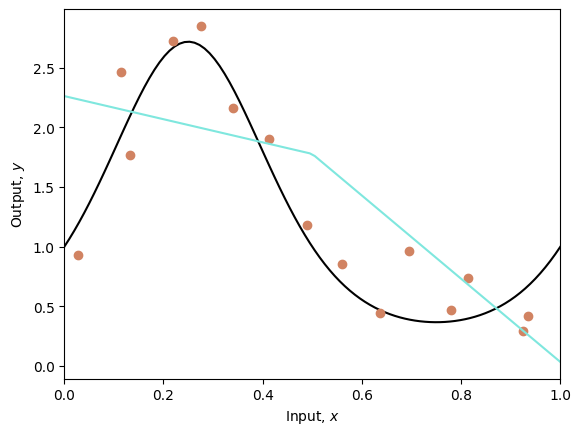

In [18]:
# TODO Draw two samples from the normal distribution over the parameters
# Replace these lines
# Draw samples from the multivariate normal distribution
phi_sample1 = np.random.multivariate_normal(phi_mean.flatten(), phi_covar, 1).T
phi_sample2 = np.random.multivariate_normal(phi_mean.flatten(), phi_covar, 1).T


# Run the network for these two sample sets of parameters
y_model_sample1 = network(x_model, phi_sample1[-1], phi_sample1[0:n_hidden])
y_model_sample2 = network(x_model, phi_sample2[-1], phi_sample2[0:n_hidden])

# Draw the two models
plot_function(x_func, y_func, x_data, y_data, x_model, y_model_sample1)
plot_function(x_func, y_func, x_data, y_data, x_model, y_model_sample2)

Now we need to perform inference for a new data points $\mathbf{x}^*$ with corresponding hidden values $\mathbf{h}^*$.  Instead of having a single estimate of the parameters, we have a distribution over the possible parameters.  So we marginalize (integrate) over this distribution to account for all possible values:

\begin{align}
Pr(y^*|\mathbf{x}^*)  &= \int Pr(y^{*}|\mathbf{x}^*,\boldsymbol\phi)Pr(\boldsymbol\phi|\{\mathbf{x}_{i},\mathbf{y}_{i}\}) d\boldsymbol\phi\\
&= \int \text{Norm}_{y^*}\bigl[[\mathbf{h}^{*T},1]\boldsymbol\phi,\sigma^2\bigr]\cdot\text{Norm}_{\boldsymbol\phi}\biggl[\frac{1}{\sigma^2}\left(\frac{1}{\sigma^2}\mathbf{H}\mathbf{H}^T+\frac{1}{\sigma_p^2}\mathbf{I}\right)^{-1}\mathbf{H}\mathbf{y},\left(\frac{1}{\sigma^2}\mathbf{H}\mathbf{H}^T+\frac{1}{\sigma_p^2}\mathbf{I}\right)^{-1}\biggr]d\boldsymbol\phi\\
&= \text{Norm}_{y^*}\biggl[\frac{1}{\sigma^2} [\mathbf{h}^{*T},1]\left(\frac{1}{\sigma^2}\mathbf{H}\mathbf{H}^T+\frac{1}{\sigma_p^2}\mathbf{I}\right)^{-1}\mathbf{H}\mathbf{y},  [\mathbf{h}^{*T},1]\left(\frac{1}{\sigma^2}\mathbf{H}\mathbf{H}^T+\frac{1}{\sigma_p^2}\mathbf{I}\right)^{-1}
[\mathbf{h}^*;1]\biggr],
\end{align}

where the notation $[\mathbf{h}^{*T},1]$ is a row vector containing $\mathbf{h}^{*T}$ with a one appended to the end and $[\mathbf{h}^{*};1 ]$ is a column vector containing $\mathbf{h}^{*}$ with a one appended to the end.


To compute this, we reformulated the integrand using the relations from appendices C.3.3 and C.3.4 as the product of a normal distribution in $\boldsymbol\phi$ and a constant with respect
to $\boldsymbol\phi$. The integral of the normal distribution must be one, and so the final result is just the constant. This constant is itself a normal distribution in $y^*$. <br>

If you feel so inclined you can work through the math of this yourself.



In [15]:
# Predict mean and variance of y_star from x_star
def inference(x_star, x_data, y_data, sigma_sq, sigma_p_sq, n_hidden):

  # Compute hidden variables for x_star
  h_star = compute_H(x_star, n_hidden);

  # Compute H matrix for training data
  H = compute_H(x_data, n_hidden);

  # The text indicates y is a column vector, so reshape y_data
  y_data_col = y_data.reshape(-1, 1)

  # Compute K = (1/sigma_sq * H @ H.T + 1/sigma_p_sq * I)^-1
  term1 = (1/sigma_sq) * np.matmul(H, np.transpose(H))
  term2 = (1/sigma_p_sq) * np.identity(n_hidden+1)
  K = np.linalg.inv(term1 + term2)

  # Reshape h_star for matrix multiplication based on the formula
  # The formula uses [h_star.T, 1] as a row vector, so we need the transpose of h_star, and h_star has n_hidden+1 rows
  h_star_row_vector = h_star # h_star is already in (n_hidden+1, 1) form, treating it as row vector after transpose

  # Compute mean of y*
  # y_star_mean = 1/sigma_sq * h_star_row_vector.T @ K @ H @ y
  y_star_mean = (1/sigma_sq) * np.matmul(np.transpose(h_star_row_vector), np.matmul(K, np.matmul(H, y_data_col)))

  # Compute variance of y*
  # y_star_var = h_star_row_vector.T @ K @ h_star_col_vector + sigma_sq
  # Note: The original formula in the text cell for variance was missing the sigma_sq term, which accounts for measurement noise.
  y_star_var = np.matmul(np.transpose(h_star_row_vector), np.matmul(K, h_star_row_vector)) + sigma_sq

  return y_star_mean[0,0], y_star_var[0,0] # Return scalar values

/tmp/ipykernel_1423/1013648060.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H[i,j] = np.maximum(0, line_vals)


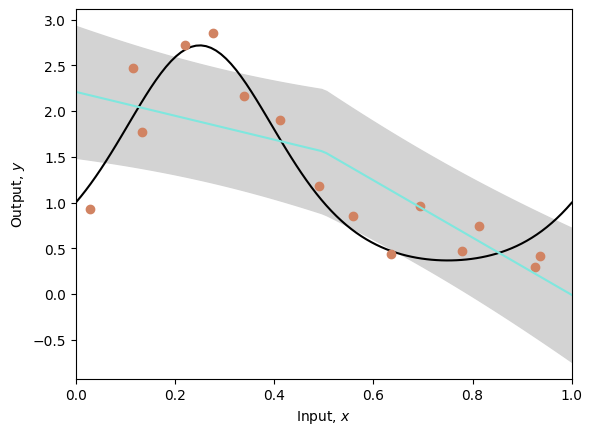

In [19]:
x_model = x_func
y_model = np.zeros_like(x_model)
y_model_std = np.zeros_like(x_model)
for c_model in range(len(x_model)):
  y_star_mean, y_star_var = inference(x_model[c_model]*np.ones((1,1)), x_data, y_data, sigma_sq, sigma_p_sq, n_hidden)
  y_model[c_model] = y_star_mean
  y_model_std[c_model] = np.sqrt(y_star_var)

# Draw the model
plot_function(x_func, y_func, x_data, y_data, x_model, y_model, sigma_model=y_model_std)

TODO:

1.  Experiment running this again with different numbers of hidden units.  Make a prediction for what will happen when you increase / decrease them.
-Initial n_hidden = 5 (Default Configuration):

The model showed a reasonable balance, fitting the data points fairly well while also exhibiting some uncertainty (represented by the grey band and the two different sampled functions).
The mean model (light blue line) provided a relatively smooth approximation of the true function, capturing its general trend.
Increasing n_hidden to 10:

Prediction: I predicted that increasing hidden units would lead to more flexibility, potentially a more accurate fit, but also a higher risk of overfitting or more variability in sampled functions.
Observed Results: With n_hidden = 10, the mean model (light blue line) generally showed a slightly smoother and more refined fit to the data. The model gained more capacity, allowing it to potentially capture more nuances of the true function. However, the sampled functions from the posterior still showed variability, indicating the uncertainty in parameter choices that lead to similar overall fits. In this specific case, due to the nature of the ReLU basis functions and the averaging effect of the Bayesian posterior, the mean function didn't necessarily become 'wigglier' but rather a more confident smooth curve that better approximated the true function in some areas, and the uncertainty bands could become narrower where data was dense.
Decreasing n_hidden to 2:

Prediction: I predicted that decreasing hidden units would make the model less flexible, leading to underfitting and a simpler, constrained fit.
Observed Results: As predicted, with n_hidden = 2, the model significantly underfitted the data. The mean model became much simpler, appearing as a few piecewise linear segments that struggled to capture the sinusoidal shape of the true function. It barely followed the general trend of the data points. The uncertainty band was also quite wide in regions, reflecting that even with fewer parameters, the model still had difficulty making confident predictions when it couldn't properly fit the underlying pattern. This clearly demonstrates that insufficient model capacity leads to underfitting.
2.  Experiment with what happens if you make the prior variance $\sigma^2_p$ to a smaller value like 1.  How do you explain the results?
-Initial sigma_p_sq = 1000 (Diffuse Prior) with n_hidden = 5:

Our initial prior was very broad, indicating little prior knowledge about the parameter values. This allowed the data to primarily drive the learning, leading to parameter values that could be quite large if the data suggested it.
Decreasing sigma_p_sq to 1 (Informative Prior) with n_hidden = 5:

Prediction: I predicted that a smaller prior variance would act as a stronger regularization, pulling parameters closer to zero, resulting in a smoother function less prone to noise, and more constrained samples.
Observed Results: With sigma_p_sq = 1, the mean model (light blue line) became noticeably smoother and less 'reactive' to individual data points. The prior, being more informative and centered around zero, exerted a stronger influence, effectively penalizing large parameter values. This forced the model's parameters to be smaller, which in turn leads to a simpler, less complex function. The model still attempted to fit the data, but it did so in a more constrained manner, reflecting a stronger belief that parameter values should not deviate much from zero. The uncertainty bands might also appear somewhat different, reflecting this regularization. In essence, a smaller prior variance acts as a form of regularization, preventing the model from becoming too complex or sensitive to noise, effectively favoring simpler explanations for the data.